In [1]:
require(data.table)
require(tidyverse)
require(dplyr)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

Loading required package: data.table

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second(

In [2]:

# look at how many reads per sample, are there any samples needed to exclude
## dig into Date_16S
### post dada2 (before making ps object)- distribution of read lengths are the same (specif for Date_16S)
### track df

# rerun post phyloseq 
## post dada2 16S figures to find what data we are working with
### reads distributed (across samples, spec, Health_status, seq_run, Month_year)

## consolidating dada2 runs

In [3]:
track1=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_Seqnums_16S.csv")

track2=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_Seqnums_16S.csv")

track3=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_Seqnums_16S.csv")

track4=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_Seqnums_16S.csv")

track5=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_Seqnums_16S.csv")

In [4]:
track <- bind_rows(track1, track2, track3, track4, track5)

In [5]:
asv1=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_16S_ASV_nochim.csv")

asv2=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_ASV_nochim.csv")

asv3=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_16S_ASV_nochim.csv")

asv4=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_16S_ASV_nochim.csv")

asv5=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_16S_ASV_nochim.csv")

problem! asv table should NOT have NA values

bine rows is not appropriate for asv_tables

## instead use dada2 merging feature

seqtabs <- list(seqtab1, seqtab2, seqtab3, seqtab4, seqtab5)

seqtab.all <- mergeSequenceTables(seqtabs)

In [6]:
asv <- bind_rows(asv1, asv2, asv3, asv4, asv5)

In [25]:


asv_1 <- read.csv("Run1_16S_ASV_nochim.csv", row.names = 1)

sum(is.na(asv_1))

Warning message in file(file, "rt"):
“cannot open file 'Run1_16S_ASV_nochim.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [7]:
taxa1=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run1_16S_taxa.csv", header=TRUE, row.names=1)

taxa2=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run2_16S_taxa.csv", header=TRUE, row.names=1)

taxa3=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run3_16S_taxa.csv", header=TRUE, row.names=1)

taxa4=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run4_16S_taxa.csv", header=TRUE, row.names=1)

taxa5=read.csv(file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/ASVs/Run5_16S_taxa.csv", header=TRUE, row.names=1)

In [8]:
taxa <- bind_rows(taxa1, taxa2, taxa3, taxa4, taxa5)

In [9]:
meta=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/meta_PCR.csv", header=TRUE)

In [10]:
head(track)

V1,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024-BEL-CBC-T1-557-SSID,140907,132539,130818,130771,127036,118800
012024-BEL-CBC-T1-563-PSTR,97665,89798,89392,89308,88670,48116
012024-BEL-CBC-T2-601-OFAV,263467,250569,249704,249707,248016,191585
012024-BEL-CBC-T2-605-SSID,605361,574264,571735,571551,564520,517961
012024-BEL-CBC-T3-627-PAST,1656969,1561240,1540358,1539923,1487115,1323604
012024-BEL-CBC-T3-631-MCAV,513353,484960,483847,483931,476841,424109


In [11]:
nrow(track)

[1] 484

In [12]:
setnames(track, c("V1"), c("Tubelabel_species"), skip_absent=TRUE)
# Step 1: Replace '-' with '_' in asv_clean$Tube
track$Tubelabel_species <- gsub("-", "_", track$Tubelabel_species)
head(track)

Tubelabel_species,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024_BEL_CBC_T1_557_SSID,140907,132539,130818,130771,127036,118800
012024_BEL_CBC_T1_563_PSTR,97665,89798,89392,89308,88670,48116
012024_BEL_CBC_T2_601_OFAV,263467,250569,249704,249707,248016,191585
012024_BEL_CBC_T2_605_SSID,605361,574264,571735,571551,564520,517961
012024_BEL_CBC_T3_627_PAST,1656969,1561240,1540358,1539923,1487115,1323604
012024_BEL_CBC_T3_631_MCAV,513353,484960,483847,483931,476841,424109


In [13]:
#exclude samples that are not in asv_clean
track_meta_all <- merge(meta, track, by = "Tubelabel_species", all = FALSE)

In [14]:
track_meta <- track_meta_all[track_meta_all$nonchim > 10000, ]

In [15]:
head(track_meta)

Tubelabel_species,X,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,⋯,Date_16S,Date_ITS2,Seq_run,Transect,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024_BEL_CBC_T1_557_SSID,1,2_17_2025,44.6,,,12024,1_3,1/10/24,SSID,⋯,3_4_2025,7_7_2025,1,CBC30N,140907,132539,130818,130771,127036,118800
012024_BEL_CBC_T1_559_MCAV,2,2_17_2025,14.8,,,12024,1_24,1/10/24,MCAV,⋯,8_22_2025,12_15_2025,2,CBC30N,1377610,1219878,1217341,1217659,1205749,206754
012024_BEL_CBC_T1_563_PSTR,4,2_17_2025,35.8,,,12024,1_12,1/10/24,PSTR,⋯,3_6_2025,7_7_2025,1,CBC30N,97665,89798,89392,89308,88670,48116
012024_BEL_CBC_T1_565_PAST,5,2_17_2025,7.72,,,12024,1_21,1/10/24,PAST,⋯,2_10_2026,2_17_2026,4,CBC30N,1214900,1099381,1088713,1087483,1029696,774055
012024_BEL_CBC_T2_585_OFAV,6,2_17_2025,71.6,,,12024,2_76,1/12/24,OFAV,⋯,2_10_2026,2_17_2026,4,SR30N,627001,565773,561251,564167,548455,350149
012024_BEL_CBC_T2_587_SSID,7,2_17_2025,48.8,,,12024,2_72,1/12/24,SSID,⋯,1_8_2026,1_20_2026,3,SR30N,783999,566086,564336,564506,547082,355936


## distribution of nonchimera reads 
###  is this a normal number of reads 

In [16]:
#standard deviation measures the dispersion of this data set relative to the mean
sd(track_meta$nonchim, na.rm = FALSE)

[1] 595247.6

In [17]:
mean(track_meta$nonchim)

[1] 355577.3

In [18]:
median(track_meta$nonchim)

[1] 261291.5

In [19]:
sum(track_meta$nonchim)

[1] 167121312

In [20]:
head(track_meta$nonchim)

[1] 118800 206754  48116 774055 350149 355936

In [22]:
dim(track_meta)

[1] 470  25

In [24]:
head(asv)

V1,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGTTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GTTAGCGTTGTTCGGAATTACTGGGCGTAAAGCGCGTGTAGGCGGAACGATCAGTCGGAGGTGAAATCCCGGGGCTTAACCCCGGAACTGCCTTCGATACTATCGCTCTAGAGATCGGAAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGGAATTCGTAGATATTGGGAAGAACACCAGAGGCGAAGGCGACTCACTGGTCCGATACTGACGCTCAGACGCGAAAGTGTGGGG,GCAAGCGTTATCCGGAATCACTGGGCGTAAAGCGTCTGTAGGTGGTTTAGTGTGTTCTTAGTTAAATTATGAAGCCTAACTTCATGAAAAGTAAGAAAACTATTAGACTTGAGTACGATAGGGGTAAGAGGAATTCTTCGAGAAGTAGTGAAATGCGAAGATACGAAGGAGAAGATCATAAGCGAAGGCTTCTTACTGGGTCGTAACTGACACTGAGAGACGAAAGCTAGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTTTTAAGTCTACTGTTAAATCTTAAGGCTTAACCTTAAAAAAGCGGTATGAAACTGAAAAGCTTGAGTTTAGTAGGGGTAGAGGGAATTCTCGGTGTAGTGGTGAAATGCGTAGAGATCGAGAAGAACACCGGTAGCGAAGGCGCTCTGCTGGGCTAAAACTGACACTGAGAGACGAAAGCTAGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,⋯,ATAAGAGACAGTGTGTCAGCAGCCTCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATGGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCGAACAGGATTAGAAACCCGAGTAGTCCCCTGTCTCTTATACACATCTC,ATAAGAGACAGGGTGTCAGCCGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,ATAAGAGACAGCGTGTCAGCAGCCGCGGTGAAACTTAAGGGTTTGTTTTTTAGAAAAAGCAGAAAGCGTGTAAAGGTAAAACATTTAAAATAAATAGAATTTTTTTAGTAATAGTGCAATATTAAAAGAAAAAAAAGAATTTTTTATGTGAAGACAATTTATTTTTTTTCTTTAACACGAAGGTTCTGGGAGCAAACAGGATTAGATACCCCTGTAGTCCGCCTGTCCCACGAGACAACAG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGTGGGGGGGGGTTTTTTTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACAGCAGATGATCTGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGACGAATGATCTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TTATACACATCTCCGAGCCCACGAGACGCATGTCTATCTGGTGGGGGGGGTTGTGGTTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG,TCTTATACACATCTCCGAGCCCACGAGACCGAGACTAATCTGGGGGGGGGGGGTGGGGGTGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG

In [23]:
rowSums(asv)

ERROR: Error in base::rowSums(x, na.rm = na.rm, dims = dims, ...): 'x' must be numeric


## ANOVA test hypotheses:
- Null hypothesis: the means of the different groups are the same
- Alternative hypothesis: At least one sample mean is not equal to the others

In [ ]:
## since Seq_run and Date16S are basically the same they s hould not go in the same anova

In [16]:
# Compute the analysis of variance
nonchim.anov <- aov(nonchim ~ Date_16S + factor(Month_year) + Species + Health_status, data = track_meta)
# Summary of the analysis
summary(nonchim.anov)


                    Df    Sum Sq   Mean Sq F value   Pr(>F)    
Date_16S            29 3.852e+13 1.328e+12   4.754 1.49e-13 ***
factor(Month_year)  11 4.410e+12 4.009e+11   1.435  0.15428    
Species              5 4.422e+12 8.844e+11   3.165  0.00811 ** 
Health_status        3 7.033e+11 2.344e+11   0.839  0.47310    
Residuals          424 1.185e+14 2.795e+11                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

#### So in Model 1:

- A lot of variation is already absorbed by Date_16S
Less variation is left for Species
- Species still significant, but weaker (p = 0.008)

- include a 29-level factor which soaks up a huge amount of variance (see your Sum Sq)
- Leaves less residual structure for Species, therefore Species looks more significant (p = 0.008) because residual variance is lower

#### model 2
- It removes less variation than Date
More variation remains for Species to explain
- Species appears more significant (p = 0.042)

In [15]:
batch.anov <- aov(nonchim ~ + factor(Month_year) + factor(Seq_run) + Species + Health_status, data = track_meta)
summary(batch.anov)

                    Df    Sum Sq   Mean Sq F value Pr(>F)  
factor(Month_year)  11 4.760e+12 4.327e+11   1.275 0.2359  
factor(Seq_run)      4 4.223e+12 1.056e+12   3.111 0.0152 *
Species              5 3.935e+12 7.870e+11   2.319 0.0426 *
Health_status        3 1.246e+12 4.155e+11   1.224 0.3004  
Residuals          449 1.524e+14 3.394e+11                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [19]:
#check if seq run is controlling which species

In [20]:
xtabs(~ Species + Seq_run, data = track_meta)

       Seq_run
Species  1  2  3  4  5
   MCAV 27 30 26 29 26
   OANN  4  1  3  6  4
   OFAV 17 13 19  8  7
   PAST 18 22 15 19 24
   PSTR 17 11  8 21 12
   SSID 12 18 22 12 22

In [28]:
# anova type2

install.packages("car")
library(car)
type2 <- Anova(lm(nonchim ~ Date_16S + Month_year + Species + Health_status, data = track_meta), type = "II")

summary(type2)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



     Sum Sq                Df           F value             Pr(>F)        
 Min.   :8.817e+08   Min.   :  1.0   Min.   :0.003097   Min.   :0.000000  
 1st Qu.:1.753e+11   1st Qu.:  3.0   1st Qu.:0.154653   1st Qu.:0.007948  
 Median :4.314e+12   Median :  5.0   Median :1.617873   Median :0.451703  
 Mean   :3.333e+13   Mean   : 94.4   Mean   :1.978752   Mean   :0.464764  
 3rd Qu.:3.861e+13   3rd Qu.: 29.0   3rd Qu.:3.441972   3rd Qu.:0.908519  
 Max.   :1.236e+14   Max.   :434.0   Max.   :4.676163   Max.   :0.955648  
                                     NA's   :1          NA's   :1         

In [29]:
#nonchim is a single continuos variable, not meant to be used with adonis
class(track_meta$nonchim)

[1] "integer"

## violin plots comparing reads

In [23]:
#wider plots
#making plots small 
options(repr.plot.width = 25, repr.plot.height = 15)

In [ ]:
## plot nochim reads vs seq run  

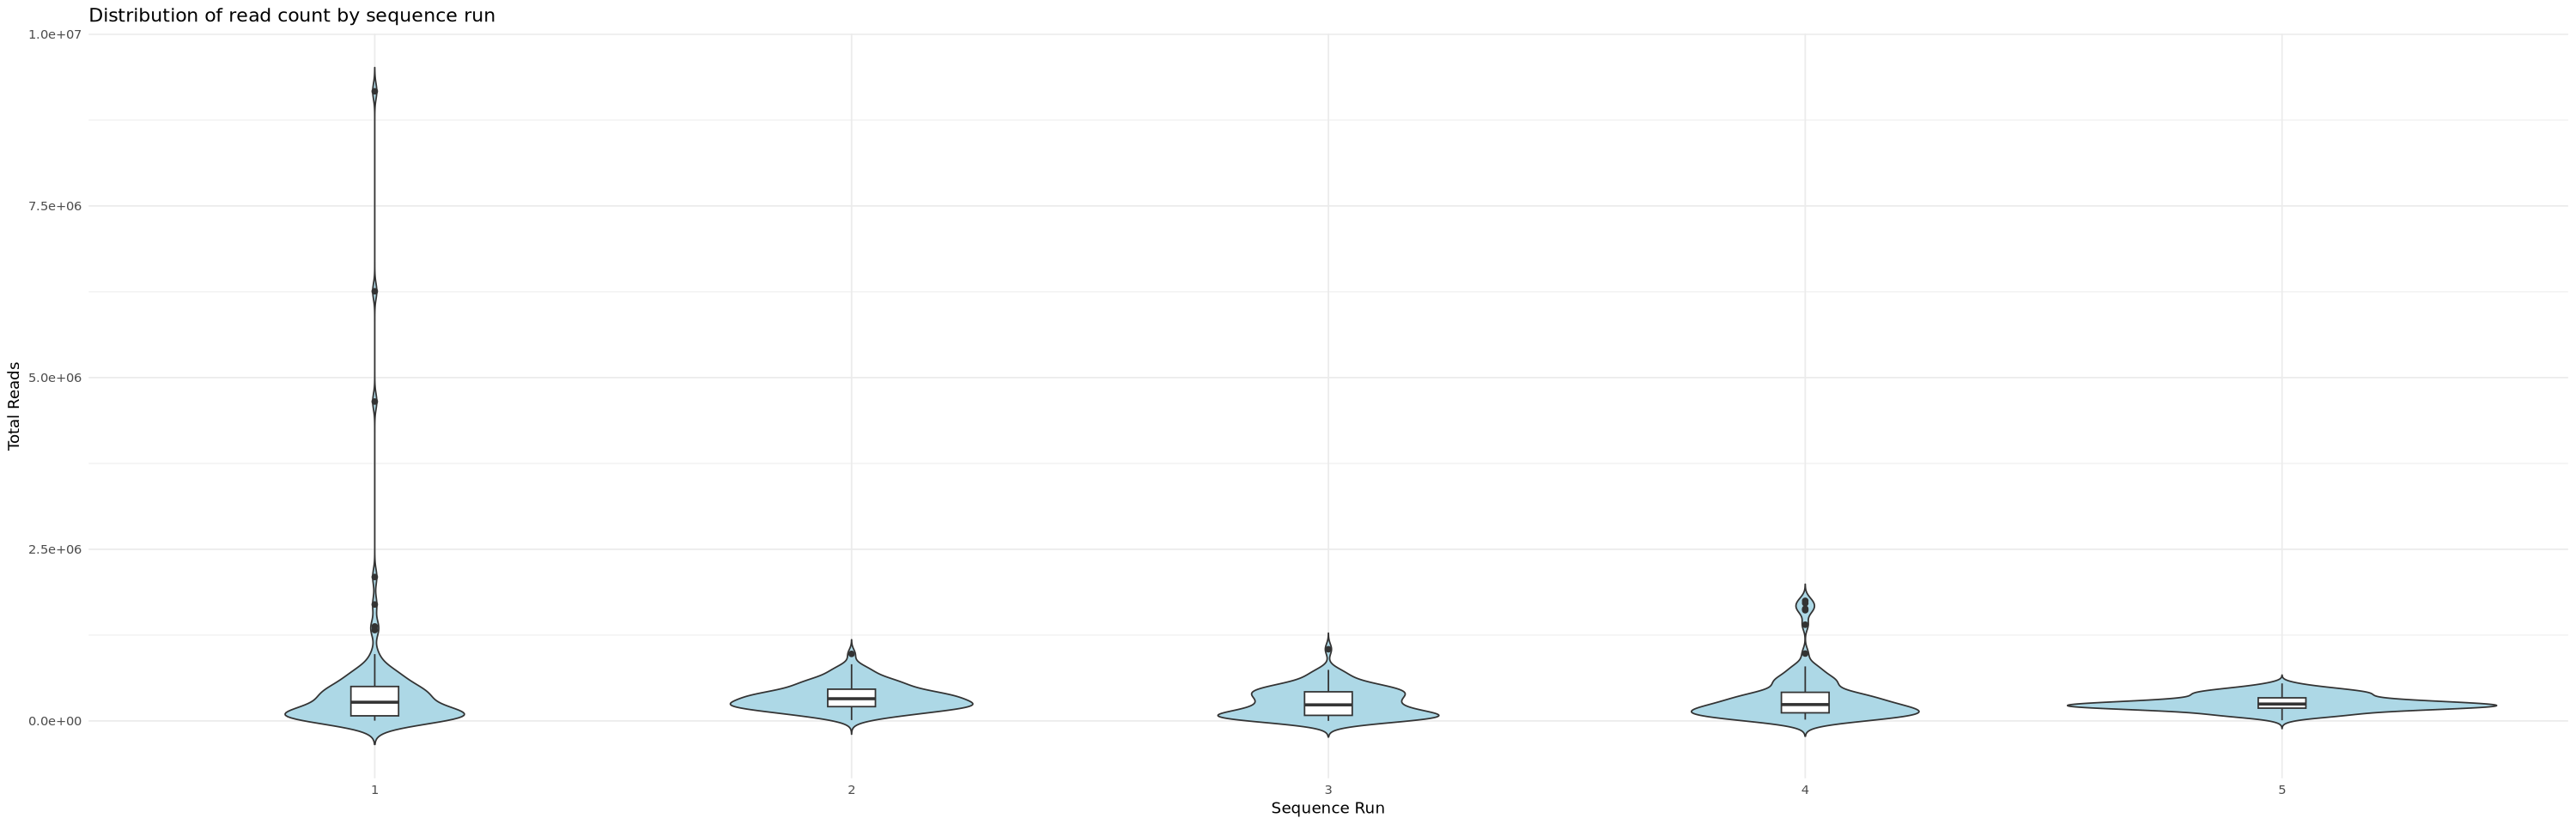

In [20]:
#using a violin plot to visualize the distribution of length of reads (y) and y or no double banding (x)
ggplot(track_meta, aes(x = factor(Seq_run), y = nonchim)) +
  geom_violin(trim = FALSE, fill = "lightblue") +
  geom_boxplot(width = 0.1) +
  labs(x = "Sequence Run", y = "Total Reads",
       title = "Distribution of read count by sequence run") +
  theme_minimal()

In [24]:
## plot nochim reads vs Daet_16S

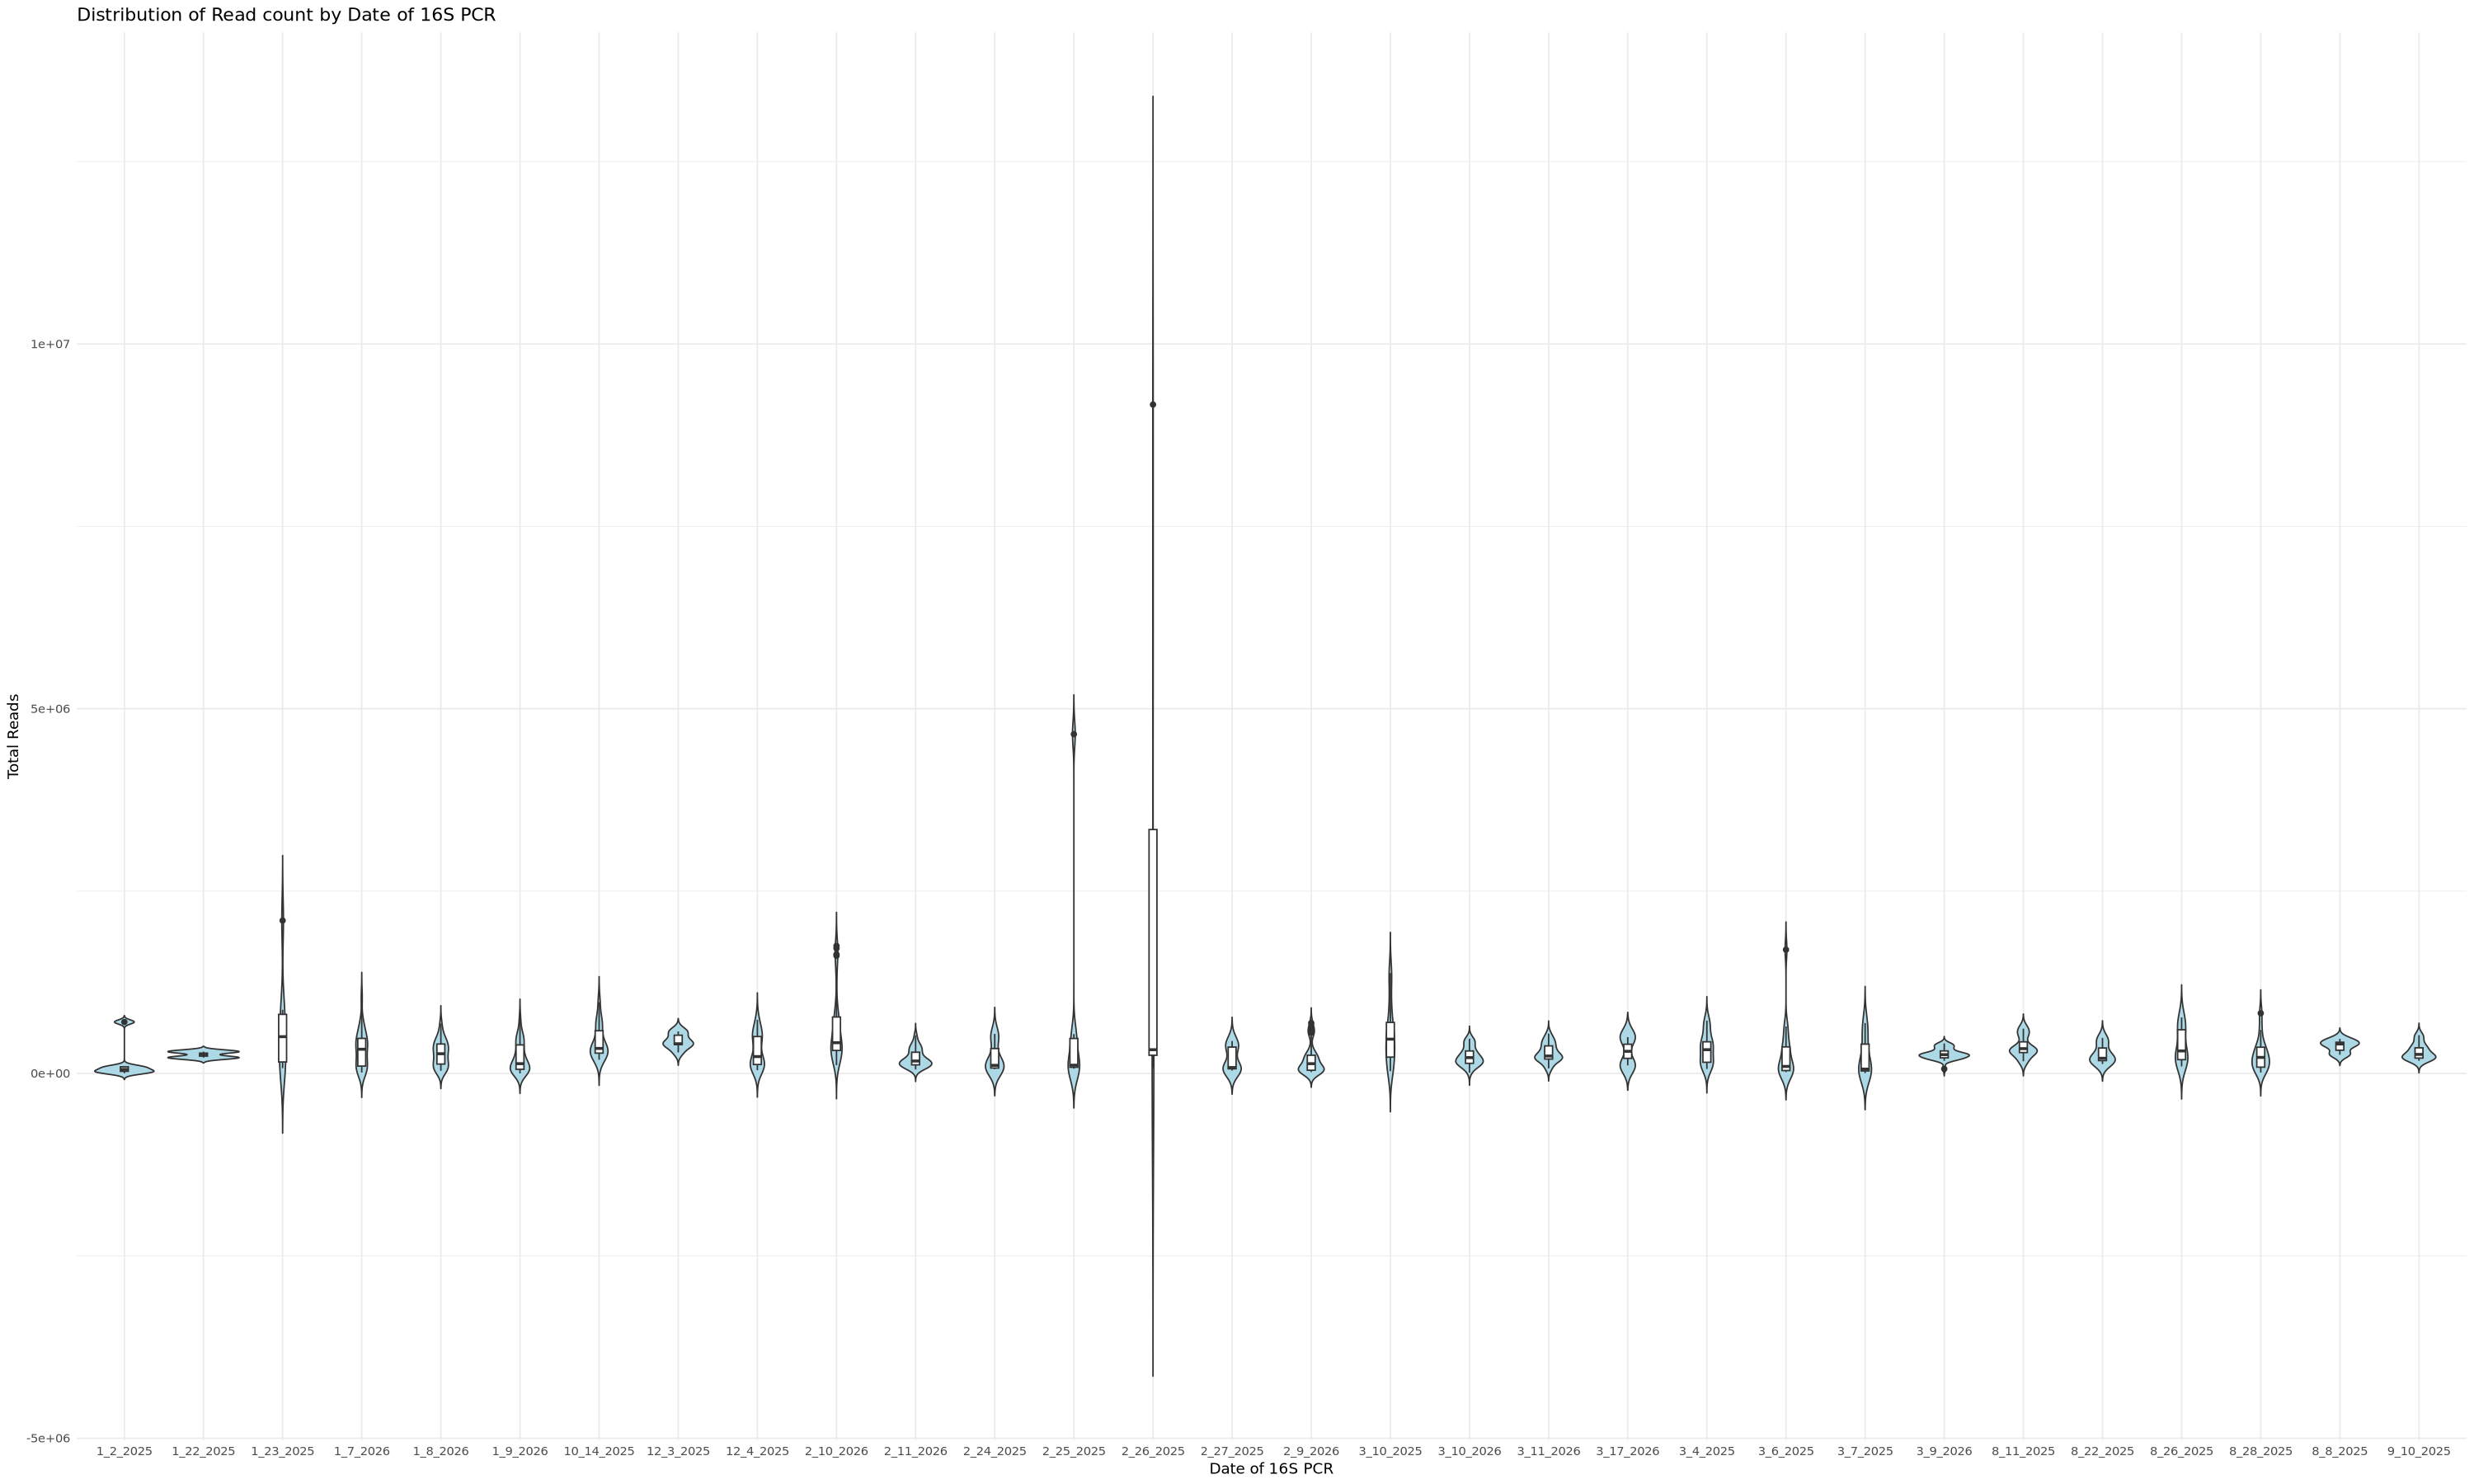

In [25]:
#using a violin plot to visualize the distribution of length of reads (y) and y or no double banding (x)
ggplot(track_meta, aes(x = factor(Date_16S), y = nonchim)) +
  geom_violin(trim = FALSE, fill = "lightblue") +
  geom_boxplot(width = 0.1) +
  labs(x = "Date of 16S PCR", y = "Total Reads",
       title = "Distribution of Read count by Date of 16S PCR") +
  theme_minimal()

## what is in 2_26_2025?

### concentrations:

| 2_26_2025 samples   | SampleNum|Conc.ng/ul|  Vol Added  |Total ng|
| ------------------- | ---------| -------  | ----------- | ------ |
| 062024_T2_1375_SSID |33        | 0.622    | 48.23151125 | 30     |
| 082024_T3_1558_MCAV |34        | 10.7     | 2.803738318 | 30     |
| 062024_T3_1442_OFAV |35        | 7.14     | 4.201680672 | 30     |
| 082024_T1_1482_OANN |36        | 21       | 1.428571429 | 30     |
| 092023_T2_184_MCAV  |37        | 0.714    | 42.01680672 | 30     |
| 082024_T3_1561_MCAV |38        | 10.4     | 2.884615385 | 30     |
| 122023_T3_524_OFAV  |39        | 14.2     | 2.112676056 | 30     |
 


In [41]:
# there are 7 2_26_2025

clean_meta <- meta[meta$Date_16S != "2_26_2025", ]

#check to make sure clean_track matches asv_clean
nrow(meta)
nrow(clean_meta)

[1] 483

[1] 476

Joining with `by = join_by(X, Tubelabel_species, Date_Extracted, Raw_ng_ul,
Date_Enriched, Microbe_Location, Month_year, colony, CollectionDate, Species,
Health_status, Sample_physical_location, Extraction_physical_location,
immune_y.n, Condition, Date_16S, Date_ITS2, Seq_run, Transect)`


X,Tubelabel_species,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,Extraction_physical_location,immune_y.n,Condition,Date_16S,Date_ITS2,Seq_run,Transect
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
196,082024_BEL_CBC_T1_1482_OANN,1_14_2025,15.9,,,82024,1_25,8/22/24,OANN,Bleached_Tissue,UML_NARWHAL_R5_B27,UML_NARWHAL_R2_B15,y,Healthy,2_26_2025,7_2_2025,1,CBC30N
245,092023_BEL_CBC_T2_184_MCAV,11_8_2024,18.9,,,92023,2_60,9/26/23,MCAV,Bleached_Tissue,UML_NARWHAL_R1_B10,UML_NARWHAL_R2_B12,y,"CLP,CLB",2_26_2025,7_2_2025,1,SR30N
214,082024_BEL_CBC_T3_1558_MCAV,1_15_2025,RECHECK,,,82024,3_14,8/24/24,MCAV,Healthy,UML_NARWHAL_R5_B27,UML_NARWHAL_R2_B15,y,Healthy,2_26_2025,7_2_2025,1,Lagoon
184,062024_BEL_CBC_T3_1442_OFAV,1_13_2025,71.4,,,62024,3_39,6/20/24,OFAV,Healthy,UML_NARWHAL_R5_B26,UML_NARWHAL_R2_B15,y,Healthy,2_26_2025,7_2_2025,1,Lagoon
164,062024_BEL_CBC_T2_1375_SSID,12_4_2024,71,,,62024,2_73,6/21/24,SSID,Healthy,UML_NARWHAL_R5_B26,UML_NARWHAL_R2_B15,y,DC,2_26_2025,7_2_2025,1,SR30N
217,082024_BEL_CBC_T3_1561_MCAV,1_15_2025,73.6,,,82024,3_21,8/24/24,MCAV,Healthy,UML_NARWHAL_R5_B27,UML_NARWHAL_R2_B15,y,Healthy,2_26_2025,7_3_2025,1,Lagoon
358,122023_BEL_CBC_T3_524_OFAV,11_19_2024,71.8,,,122023,3_38,12/16/23,OFAV,Healthy,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B13,y,Healthy,2_26_2025,7_3_2025,1,Lagoon


In [35]:
clean_track_meta <- merge(clean_meta, track, by = "Tubelabel_species", all = FALSE)

In [40]:
## how many reads did the 2_26_2025 smaples have?

#which samples got removed for removing 2_26_2025
anti_join(track_meta, clean_track_meta, by = NULL, copy = FALSE)

Joining with `by = join_by(Tubelabel_species, X, Date_Extracted, Raw_ng_ul,
Date_Enriched, Microbe_Location, Month_year, colony, CollectionDate, Species,
Health_status, Sample_physical_location, Extraction_physical_location,
immune_y.n, Condition, Date_16S, Date_ITS2, Seq_run, Transect, input, filtered,
denoisedF, denoisedR, merged, nonchim)`


Tubelabel_species,X,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,⋯,Date_16S,Date_ITS2,Seq_run,Transect,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
062024_BEL_CBC_T2_1375_SSID,164,12_4_2024,71,,,62024,2_73,6/21/24,SSID,⋯,2_26_2025,7_2_2025,1,SR30N,7839030,7475286,7436252,7435548,7198389,6257366
062024_BEL_CBC_T3_1442_OFAV,184,1_13_2025,71.4,,,62024,3_39,6/20/24,OFAV,⋯,2_26_2025,7_2_2025,1,Lagoon,550848,525394,523222,523421,515969,430259
082024_BEL_CBC_T1_1482_OANN,196,1_14_2025,15.9,,,82024,1_25,8/22/24,OANN,⋯,2_26_2025,7_2_2025,1,CBC30N,102678,96680,95355,95220,92548,76186
082024_BEL_CBC_T3_1558_MCAV,214,1_15_2025,RECHECK,,,82024,3_14,8/24/24,MCAV,⋯,2_26_2025,7_2_2025,1,Lagoon,309599,293004,290494,289784,285009,221123
082024_BEL_CBC_T3_1561_MCAV,217,1_15_2025,73.6,,,82024,3_21,8/24/24,MCAV,⋯,2_26_2025,7_3_2025,1,Lagoon,381977,361041,358237,358071,352838,277809
092023_BEL_CBC_T2_184_MCAV,245,11_8_2024,18.9,,,92023,2_60,9/26/23,MCAV,⋯,2_26_2025,7_2_2025,1,SR30N,11038444,10475194,10423957,10419368,10138067,9169329
122023_BEL_CBC_T3_524_OFAV,358,11_19_2024,71.8,,,122023,3_38,12/16/23,OFAV,⋯,2_26_2025,7_3_2025,1,Lagoon,427620,404520,399076,398423,387381,325830


## How many reads do I expect from each sample?
paired end 200-250 million total reads (R1 and r2 separate)
around 2 million reads per sample expected 

## rerun anova excluding 16S pcr from 2_26_2025


In [36]:
# Compute the analysis of variance
clean.anov <- aov(nonchim ~ Date_16S + factor(Month_year) + Seq_run + Species + Health_status, data = clean_track_meta)
# Summary of the analysis
summary(clean.anov)

                    Df    Sum Sq   Mean Sq F value   Pr(>F)    
Date_16S            28 8.936e+12 3.191e+11   3.398 3.63e-08 ***
factor(Month_year)  11 1.171e+12 1.065e+11   1.133    0.333    
Seq_run              1 7.641e+10 7.641e+10   0.814    0.368    
Species              5 3.893e+12 7.786e+11   8.290 1.75e-07 ***
Health_status        3 1.815e+11 6.049e+10   0.644    0.587    
Residuals          417 3.916e+13 9.392e+10                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

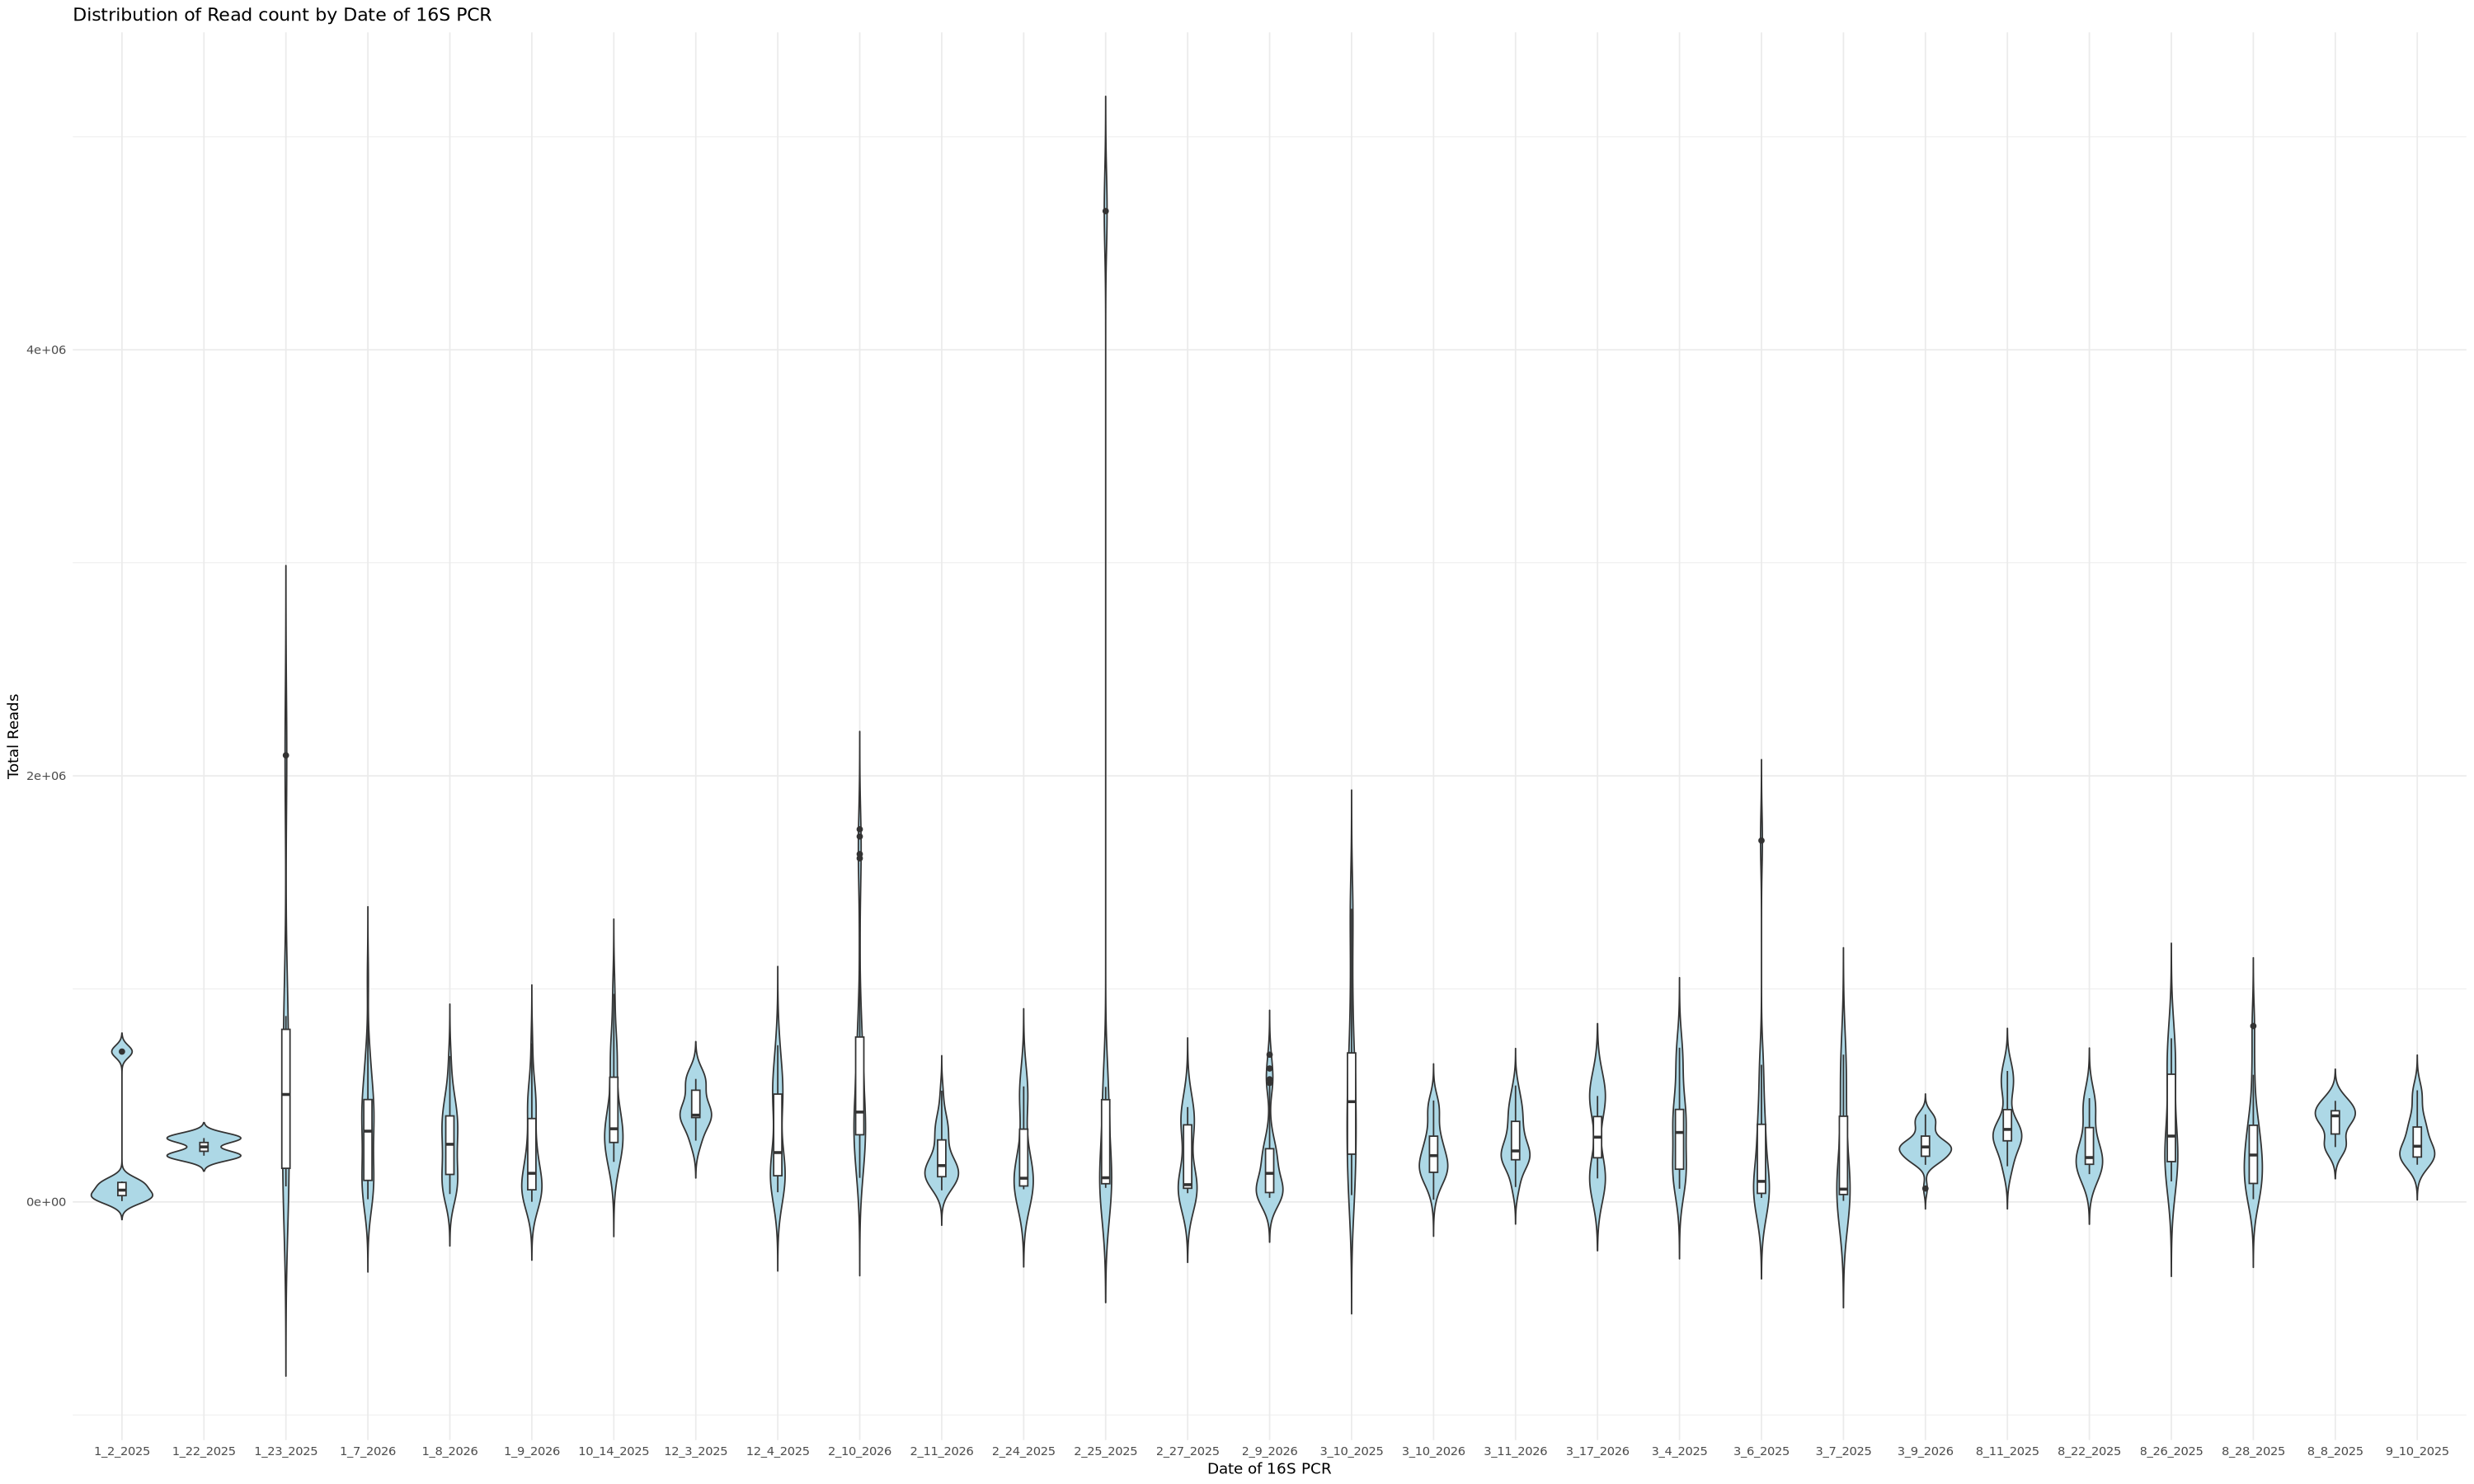

In [37]:
#using a violin plot to visualize the distribution of length of reads (y) and y or no double banding (x)
ggplot(clean_track_meta, aes(x = factor(Date_16S), y = nonchim)) +
  geom_violin(trim = FALSE, fill = "lightblue") +
  geom_boxplot(width = 0.1) +
  labs(x = "Date of 16S PCR", y = "Total Reads",
       title = "Distribution of Read count by Date of 16S PCR") +
  theme_minimal()

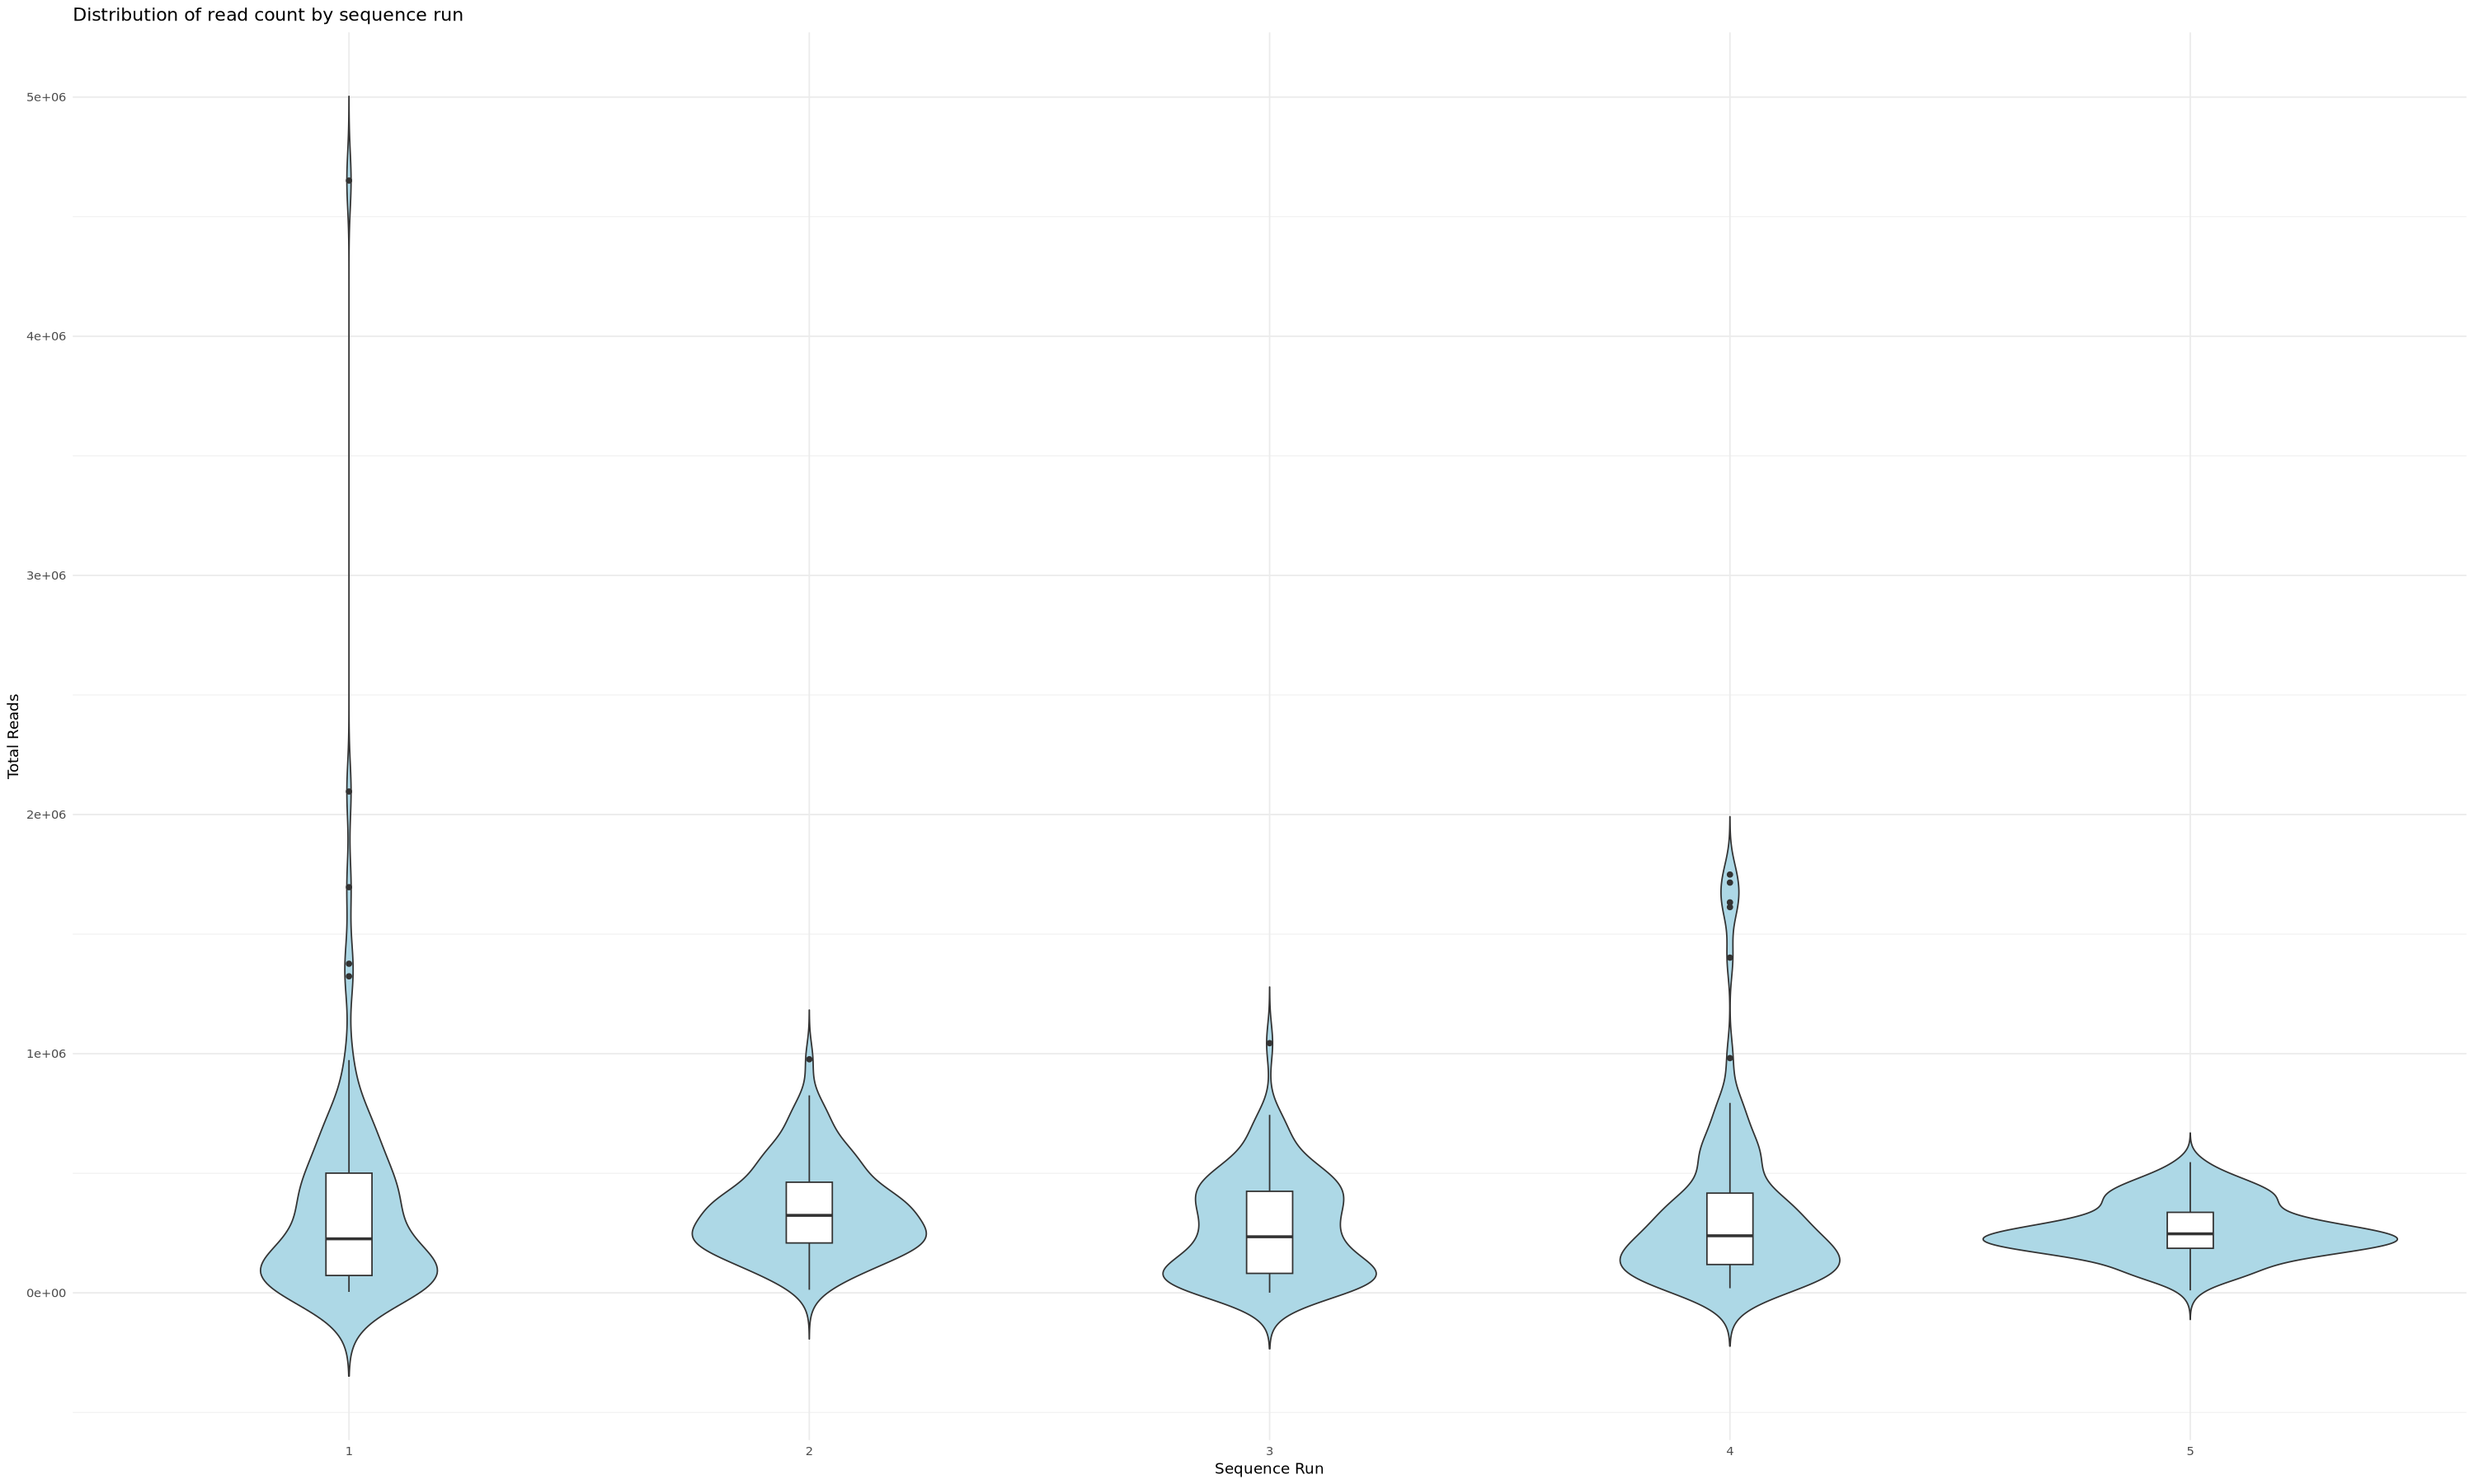

In [39]:
#using a violin plot to visualize the distribution of length of reads (y) and y or no double banding (x)
ggplot(clean_track_meta, aes(x = factor(Seq_run), y = nonchim)) +
  geom_violin(trim = FALSE, fill = "lightblue") +
  geom_boxplot(width = 0.1) +
  labs(x = "Sequence Run", y = "Total Reads",
       title = "Distribution of read count by sequence run") +
  theme_minimal()

## what is in 2_25_2026?


### concentrations

| 2_25_2026 Samples           |SampleNum|Conc. ng/ul| Vol added| Total ng |
| --------------------------- |---------| --------- | --------- | ------- |
| 082024_BEL_CBC_T4_1606_PSTR |25       | 7.58      |3.957783641| 30      |
| 112023_BEL_CBC_T1_276_MCAV  |26       | 13.4      |2.23880597 | 30      |
| 122023_BEL_CBC_T2_518_MCAV  |27       | 9.48      |3.164556962| 30      |
| 122023_BEL_CBC_T3_531_PSTR  |28       | 8.4       |3.571428571| 30     |
| 122023_BEL_CBC_T3_525_PAST  |29       | 8.14      |3.685503686| 30      |
| 112023_BEL_CBC_T3_352_PAST  |30       | 9.06      |3.311258278| 30      |
| 082024_BEL_CBC_T3_1562_OFAV |31       | 1.69      |17.75147929| 30      |



### remove 2_25_2025 as well

In [43]:
# there are 7 2_26_2025

cleaner_meta <- clean_meta[clean_meta$Date_16S != "2_25_2025", ]

#check to make sure clean_track matches asv_clean
nrow(clean_meta)
nrow(cleaner_meta)
#which samples got removed for removing 2_26_2025
anti_join(meta, cleaner_meta, by = NULL, copy = FALSE)

[1] 476

[1] 469

Joining with `by = join_by(X, Tubelabel_species, Date_Extracted, Raw_ng_ul,
Date_Enriched, Microbe_Location, Month_year, colony, CollectionDate, Species,
Health_status, Sample_physical_location, Extraction_physical_location,
immune_y.n, Condition, Date_16S, Date_ITS2, Seq_run, Transect)`


X,Tubelabel_species,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,Extraction_physical_location,immune_y.n,Condition,Date_16S,Date_ITS2,Seq_run,Transect
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
270,112023_BEL_CBC_T1_276_MCAV,11_13_2024,11.1,,,112023,1_24,11/14/23,MCAV,Bleached_Tissue,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B12,y,CLP,2_25_2025,6_30_2025,1,CBC30N
365,122023_BEL_CBC_T3_531_PSTR,11_19_2024,16.8,,,122023,3_70,12/16/23,PSTR,Bleached_Tissue,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B13,y,"CLP,CLB",2_25_2025,6_30_2025,1,Lagoon
351,122023_BEL_CBC_T2_518_MCAV,11_18_2024,18.8,,,122023,2_55,12/15/23,MCAV,Bleached_Tissue,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B13,y,"CLP,CLB",2_25_2025,6_30_2025,1,SR30N
222,082024_BEL_CBC_T4_1606_PSTR,1_15_2025,32.4,,,82024,4_98,8/22/24,PSTR,Bleached_Tissue,UML_NARWHAL_R5_B27,UML_NARWHAL_R2_B15,y,CLP,2_25_2025,6_30_2025,1,Curlew
359,122023_BEL_CBC_T3_525_PAST,11_19_2024,2.54,,,122023,3_6,12/16/23,PAST,Bleached_Tissue,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B13,y,CLB,2_25_2025,6_30_2025,1,Lagoon
218,082024_BEL_CBC_T3_1562_OFAV,1_15_2025,76,,,82024,3_39,8/24/24,OFAV,Healthy,UML_NARWHAL_R5_B27,UML_NARWHAL_R2_B15,y,Healthy,2_25_2025,7_2_2025,1,Lagoon
289,112023_BEL_CBC_T3_352_PAST,11_15_2024,9.16,,,112023,3_10,11/13/23,PAST,Bleached_Tissue,UML_NARWHAL_R5_B19,UML_NARWHAL_R2_B12,y,CLB,2_25_2025,7_2_2025,1,Lagoon
196,082024_BEL_CBC_T1_1482_OANN,1_14_2025,15.9,,,82024,1_25,8/22/24,OANN,Bleached_Tissue,UML_NARWHAL_R5_B27,UML_NARWHAL_R2_B15,y,Healthy,2_26_2025,7_2_2025,1,CBC30N
245,092023_BEL_CBC_T2_184_MCAV,11_8_2024,18.9,,,92023,2_60,9/26/23,MCAV,Bleached_Tissue,UML_NARWHAL_R1_B10,UML_NARWHAL_R2_B12,y,"CLP,CLB",2_26_2025,7_2_2025,1,SR30N


In [46]:
cleaner_track_meta <- merge(cleaner_meta, track, by = "Tubelabel_species", all = FALSE)

In [48]:
# Compute the analysis of variance
clean.anov <- aov(nonchim ~ Date_16S + factor(Month_year) + Seq_run + Species + Health_status, data = cleaner_track_meta)
# Summary of the analysis
summary(clean.anov)

                    Df    Sum Sq   Mean Sq F value   Pr(>F)    
Date_16S            27 6.948e+12 2.573e+11   4.524 5.30e-12 ***
factor(Month_year)  11 6.188e+11 5.625e+10   0.989    0.456    
Seq_run              1 7.292e+10 7.292e+10   1.282    0.258    
Species              5 3.174e+12 6.349e+11  11.162 4.22e-10 ***
Health_status        3 1.884e+11 6.281e+10   1.104    0.347    
Residuals          411 2.338e+13 5.688e+10                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

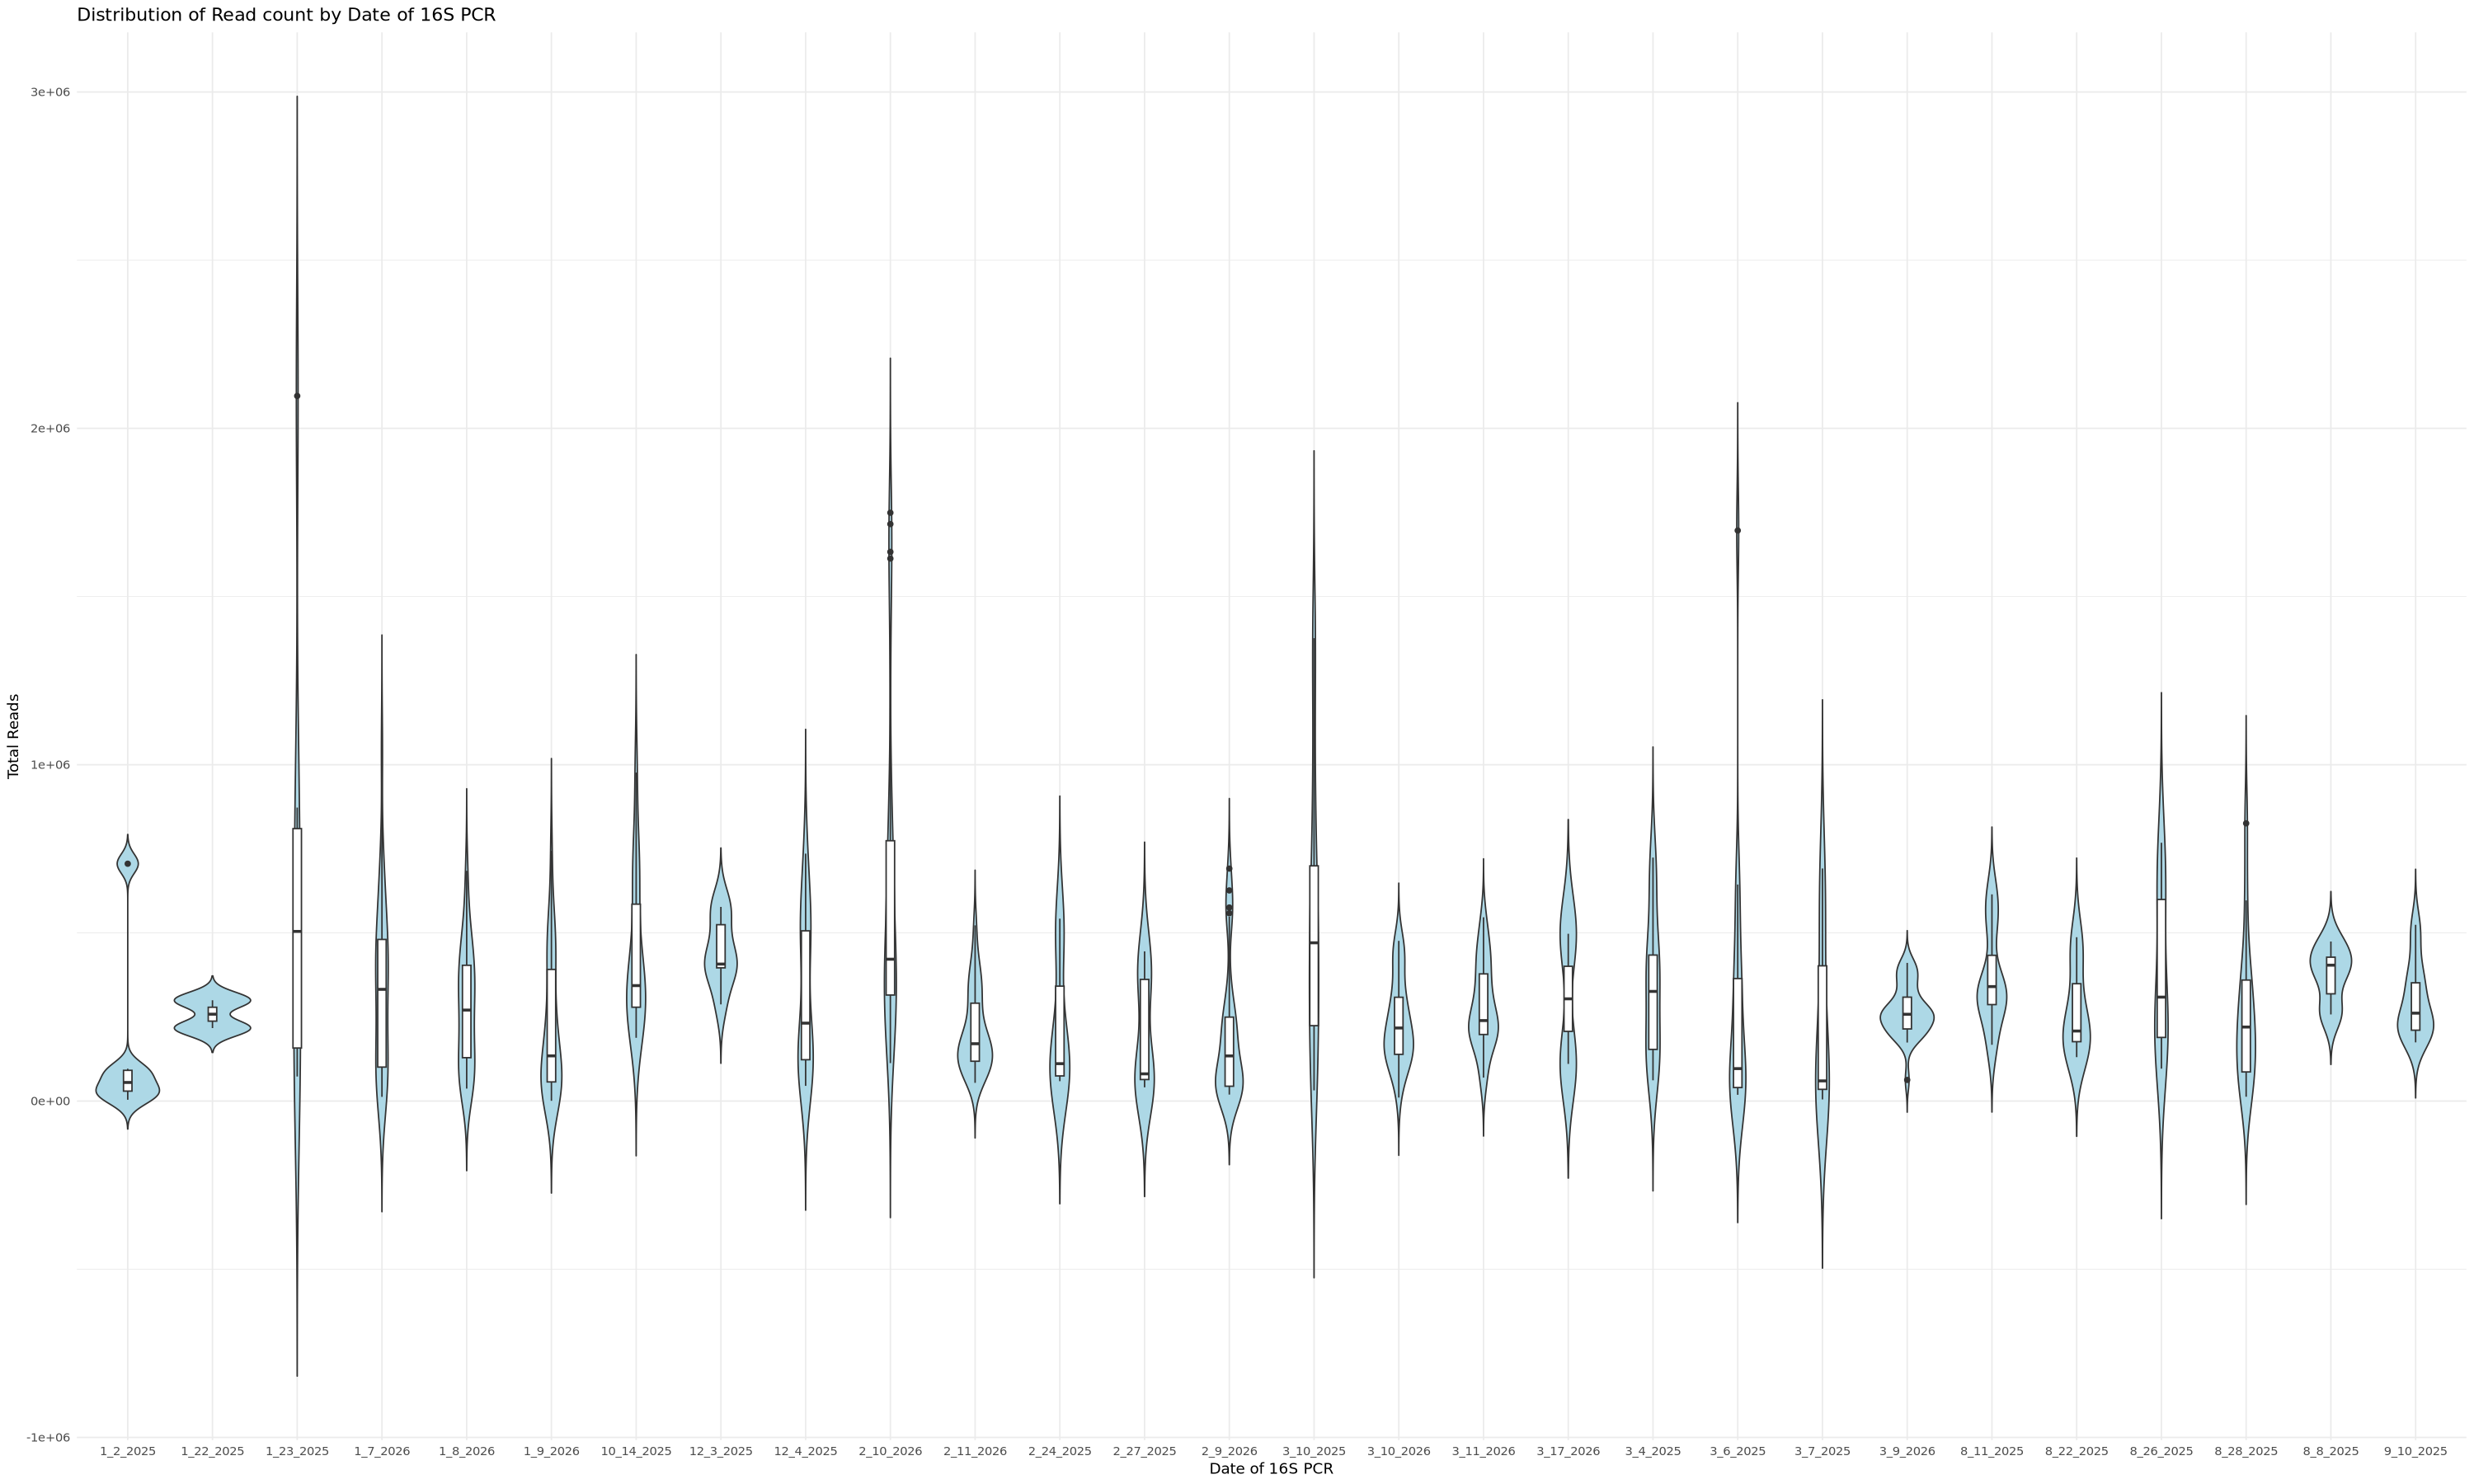

In [49]:
#using a violin plot to visualize the distribution of length of reads (y) and y or no double banding (x)
ggplot(cleaner_track_meta, aes(x = factor(Date_16S), y = nonchim)) +
  geom_violin(trim = FALSE, fill = "lightblue") +
  geom_boxplot(width = 0.1) +
  labs(x = "Date of 16S PCR", y = "Total Reads",
       title = "Distribution of Read count by Date of 16S PCR") +
  theme_minimal()

## now remove the samples where reads are below 15k after chimera removal and rerun anova

In [50]:
above15k_track <- track[track$nonchim > 15000, ]

In [51]:
head(above15k_track)

Tubelabel_species,input,filtered,denoisedF,denoisedR,merged,nonchim
<chr>,<int>,<int>,<int>,<int>,<int>,<int>
012024_BEL_CBC_T1_557_SSID,140907,132539,130818,130771,127036,118800
012024_BEL_CBC_T1_563_PSTR,97665,89798,89392,89308,88670,48116
012024_BEL_CBC_T2_601_OFAV,263467,250569,249704,249707,248016,191585
012024_BEL_CBC_T2_605_SSID,605361,574264,571735,571551,564520,517961
012024_BEL_CBC_T3_627_PAST,1656969,1561240,1540358,1539923,1487115,1323604
012024_BEL_CBC_T3_631_MCAV,513353,484960,483847,483931,476841,424109


In [52]:
cleanest_track_meta <- merge(cleaner_meta, above15k_track, by = "Tubelabel_species", all = FALSE)

In [53]:
# Compute the analysis of variance
cleanest.anov <- aov(nonchim ~ Date_16S + factor(Month_year) + Seq_run + Species + Health_status, data = cleanest_track_meta)
# Summary of the analysis
summary(cleanest.anov)

                    Df    Sum Sq   Mean Sq F value   Pr(>F)    
Date_16S            27 6.660e+12 2.467e+11   4.313 3.33e-11 ***
factor(Month_year)  11 6.911e+11 6.283e+10   1.099    0.361    
Seq_run              1 7.617e+10 7.617e+10   1.332    0.249    
Species              5 2.909e+12 5.818e+11  10.173 3.43e-09 ***
Health_status        3 1.958e+11 6.528e+10   1.141    0.332    
Residuals          402 2.299e+13 5.719e+10                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## notes 
-when I remove outliers (really high number of reads (over 3 mill) and really low (under 15K)) Date_16S becomes less significant
### why are some Dates having such high reads?